<a href="https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
# ============================================================
# ML-10 — WEEK 7 CONTENT ACTION PLAYBOOK
# Setup, repository detection, imports, and paths
# ============================================================

from pathlib import Path
import os
import json
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Find or clone the repository
# ------------------------------------------------------------

REPO_NAME = "flyrank-ml-internship-sunaina"
REPO_URL = "https://github.com/sunainakhatwani12/flyrank-ml-internship-sunaina.git"

possible_roots = [
    Path.cwd(),
    Path("/content") / REPO_NAME,
    Path("/content/drive/MyDrive") / REPO_NAME,
]

repo_root = None

for candidate in possible_roots:
    if (
        candidate.exists()
        and (candidate / "work").exists()
        and (candidate / "docs").exists()
    ):
        repo_root = candidate.resolve()
        break

if repo_root is None:
    clone_destination = Path("/content") / REPO_NAME

    if not clone_destination.exists():
        print("Repository not found in the Colab session.")
        print("Cloning the GitHub repository...")
        subprocess.run(
            ["git", "clone", REPO_URL, str(clone_destination)],
            check=True
        )

    repo_root = clone_destination.resolve()

os.chdir(repo_root)

# ------------------------------------------------------------
# 2. Create required folders
# ------------------------------------------------------------

notebooks_dir = repo_root / "work" / "notebooks"
outputs_dir = repo_root / "work" / "outputs"
figures_dir = repo_root / "work" / "figures"

notebooks_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Reproducibility settings
# ------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 80)

print("SETUP COMPLETE")
print("-" * 70)
print(f"Repository root: {repo_root}")
print(f"Notebook folder: {notebooks_dir}")
print(f"Output folder:   {outputs_dir}")
print(f"Figure folder:   {figures_dir}")

Repository not found in the Colab session.
Cloning the GitHub repository...
SETUP COMPLETE
----------------------------------------------------------------------
Repository root: /content/flyrank-ml-internship-sunaina
Notebook folder: /content/flyrank-ml-internship-sunaina/work/notebooks
Output folder:   /content/flyrank-ml-internship-sunaina/work/outputs
Figure folder:   /content/flyrank-ml-internship-sunaina/work/figures


# ML-10 — Content Action Playbook

**Lane:** Refresh / Content Opportunity Scoring

This notebook converts the validated ranking from the previous modeling and validation work into a practical content-action playbook. The output is a ranked decision-support queue, not an automated publishing system. Each recommendation includes a reason code, priority tier, estimated effort, potential value, and a human-review requirement.

The notebook follows two principles:

1. Claims must remain proportional to the evidence.
2. Model output must support human decisions rather than automatically changing content.

The notebook exports:

- A ranked action queue to `work/outputs/`
- Aggregate playbook metrics to `work/outputs/`
- Monitoring and retraining rules to `work/outputs/`
- Reusable aggregate figures to `work/figures/`

No client names, URLs, private search queries, or private content text are included in the committed artifacts.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 1 — LOAD THE BEST AVAILABLE RANKED OUTPUT
# AND BUILD THE ACTION PLAYBOOK
# ============================================================

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def first_existing_column(frame, candidates):
    """Return the first candidate column present in a dataframe."""
    for column in candidates:
        if column in frame.columns:
            return column
    return None


def numeric_series(frame, candidates, default=np.nan):
    """Return the first available candidate as a numeric Series."""
    column = first_existing_column(frame, candidates)

    if column is None:
        return pd.Series(default, index=frame.index, dtype=float)

    return pd.to_numeric(frame[column], errors="coerce")


def percentile_rank(series, neutral_value=0.5):
    """Convert a numeric Series to percentile ranks between 0 and 1."""
    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.notna().sum() == 0:
        return pd.Series(neutral_value, index=series.index, dtype=float)

    filled = numeric.fillna(numeric.median())

    if filled.nunique() <= 1:
        return pd.Series(neutral_value, index=series.index, dtype=float)

    return filled.rank(method="average", pct=True)


def normalize_score_to_100(series):
    """Normalize a score or probability to a 0–100 scale."""
    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.notna().sum() == 0:
        return pd.Series(np.nan, index=series.index, dtype=float)

    numeric = numeric.fillna(numeric.median())

    # Probabilities commonly use a 0–1 scale.
    if numeric.min() >= 0 and numeric.max() <= 1.000001:
        normalized = numeric * 100

    # Scores already using 0–100 can be kept.
    elif numeric.min() >= 0 and numeric.max() <= 100:
        normalized = numeric

    # Other score ranges are converted with percentile ranking.
    else:
        normalized = percentile_rank(numeric) * 100

    return normalized.clip(0, 100)


# ------------------------------------------------------------
# 1. Try to reuse a queue exported by earlier notebooks
# ------------------------------------------------------------

preferred_output_files = [
    outputs_dir / "w06_ranked_predictions.csv",
    outputs_dir / "w06_validation_predictions.csv",
    outputs_dir / "w06_validation_queue.csv",
    outputs_dir / "w05_ranked_predictions.csv",
    outputs_dir / "w05_model_ranked_queue.csv",
    outputs_dir / "ranked_predictions.csv",
    outputs_dir / "baseline_action_score.csv",
]

source_path = None
source_kind = None

for candidate in preferred_output_files:
    if candidate.exists():
        try:
            preview = pd.read_csv(candidate, nrows=5)

            if len(preview) > 0:
                source_path = candidate
                source_kind = "previous ranked output"
                break
        except Exception:
            pass

# ------------------------------------------------------------
# 2. If output CSVs are absent, find repository starter data
# ------------------------------------------------------------

if source_path is None:
    csv_candidates = []

    for path in repo_root.rglob("*.csv"):
        path_string = str(path).replace("\\", "/").lower()

        # Avoid using Week 7's own future export.
        if "w07_ranked_action_queue.csv" in path_string:
            continue

        # Prefer source or starter data rather than generated action queues.
        if "/work/outputs/" not in path_string:
            csv_candidates.append(path)

    # Rank likely starter/source files first.
    csv_candidates = sorted(
        csv_candidates,
        key=lambda p: (
            0 if "starter" in p.name.lower() else 1,
            0 if "data" in str(p.parent).lower() else 1,
            p.name.lower()
        )
    )

    for candidate in csv_candidates:
        try:
            preview = pd.read_csv(candidate, nrows=10)

            useful_columns = {
                "content_id",
                "page_id",
                "client_id",
                "days_since_last_update",
                "content_age_days",
                "impressions_90d",
                "avg_position",
                "ctr",
                "trend_pct",
                "trend_direction",
                "is_declining_label",
            }

            if len(set(preview.columns).intersection(useful_columns)) >= 2:
                source_path = candidate
                source_kind = "repository starter/source data"
                break
        except Exception:
            pass

if source_path is None:
    raise FileNotFoundError(
        "No usable previous queue or starter CSV was found in the repository. "
        "Confirm that the starter data included with the repository has not been deleted."
    )

raw = pd.read_csv(source_path)

if len(raw) == 0:
    raise ValueError(f"The selected source file is empty: {source_path}")

print("SOURCE SELECTED")
print("-" * 70)
print(f"Source type: {source_kind}")
print(f"Source file: {source_path.relative_to(repo_root)}")
print(f"Rows loaded: {len(raw):,}")
print(f"Columns loaded: {len(raw.columns):,}")

# ------------------------------------------------------------
# 3. Build a public-safe working dataframe
# ------------------------------------------------------------

working = pd.DataFrame(index=raw.index)

content_id_column = first_existing_column(
    raw,
    [
        "content_id",
        "page_id",
        "item_id",
        "document_id",
        "content_key",
    ]
)

client_id_column = first_existing_column(
    raw,
    [
        "client_id",
        "account_id",
        "site_id",
        "tenant_id",
    ]
)

if content_id_column is not None:
    working["content_id"] = raw[content_id_column].astype(str)
else:
    working["content_id"] = [
        f"content_{number:06d}"
        for number in range(1, len(raw) + 1)
    ]

if client_id_column is not None:
    working["client_id"] = raw[client_id_column].astype(str)
else:
    working["client_id"] = "client_unknown"

# Keep only pseudonymized identifiers. Never copy URL, title, query, or text fields.
working["days_since_last_update"] = numeric_series(
    raw,
    [
        "days_since_last_update",
        "content_age_days",
        "days_since_update",
        "age_days",
    ]
)

working["impressions_90d"] = numeric_series(
    raw,
    [
        "impressions_90d",
        "impressions",
        "total_impressions",
        "search_impressions",
    ],
    default=0
)

working["avg_position"] = numeric_series(
    raw,
    [
        "avg_position",
        "average_position",
        "position",
    ]
)

working["ctr"] = numeric_series(
    raw,
    [
        "ctr",
        "click_through_rate",
        "average_ctr",
    ]
)

working["sessions_90d"] = numeric_series(
    raw,
    [
        "sessions_90d",
        "sessions",
        "organic_sessions",
        "total_sessions",
    ]
)

working["trend_pct"] = numeric_series(
    raw,
    [
        "trend_pct",
        "trend_percent",
        "traffic_change_pct",
        "impression_change_pct",
    ]
)

decline_label_column = first_existing_column(
    raw,
    [
        "is_declining_label",
        "is_declining",
        "decline_label",
        "target",
        "label",
    ]
)

if decline_label_column is not None:
    label_raw = raw[decline_label_column]

    if pd.api.types.is_numeric_dtype(label_raw):
        working["observed_decline"] = (
            pd.to_numeric(label_raw, errors="coerce")
            .fillna(0)
            .astype(float)
            > 0
        )
    else:
        working["observed_decline"] = (
            label_raw.astype(str)
            .str.lower()
            .isin(
                [
                    "1",
                    "true",
                    "yes",
                    "declining",
                    "decline",
                    "down",
                    "negative",
                ]
            )
        )
else:
    working["observed_decline"] = working["trend_pct"].fillna(0) < 0

# ------------------------------------------------------------
# 4. Obtain or reconstruct a ranking score
# ------------------------------------------------------------

score_column = first_existing_column(
    raw,
    [
        "model_score",
        "predicted_probability",
        "prediction_probability",
        "decline_probability",
        "predicted_proba",
        "risk_probability",
        "action_score",
        "baseline_action_score",
        "score",
    ]
)

if score_column is not None:
    working["decision_score"] = normalize_score_to_100(raw[score_column])
    score_source = f"existing ranking column: {score_column}"

else:
    age_component = percentile_rank(
        working["days_since_last_update"],
        neutral_value=0.5
    )

    visibility_component = percentile_rank(
        np.log1p(working["impressions_90d"].clip(lower=0)),
        neutral_value=0.5
    )

    # A more negative trend receives a higher decline component.
    if working["trend_pct"].notna().sum() > 0:
        decline_component = percentile_rank(
            -working["trend_pct"],
            neutral_value=0.5
        )
    else:
        decline_component = working["observed_decline"].astype(float)

    # CTR weakness receives a modest weight only when CTR exists.
    if working["ctr"].notna().sum() > 0:
        ctr_weakness_component = percentile_rank(
            -working["ctr"],
            neutral_value=0.5
        )
    else:
        ctr_weakness_component = pd.Series(
            0.5,
            index=working.index,
            dtype=float
        )

    working["decision_score"] = (
        100
        * (
            0.35 * age_component
            + 0.35 * visibility_component
            + 0.20 * decline_component
            + 0.10 * ctr_weakness_component
        )
    ).clip(0, 100)

    score_source = (
        "regenerated decision-support score using staleness, visibility, "
        "decline evidence, and CTR weakness"
    )

# Remove duplicate content items by keeping the strongest row.
working = (
    working
    .sort_values("decision_score", ascending=False)
    .drop_duplicates(subset=["content_id"], keep="first")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Calculate evidence thresholds
# ------------------------------------------------------------

def safe_quantile(series, quantile, fallback):
    numeric = pd.to_numeric(series, errors="coerce").dropna()

    if len(numeric) == 0:
        return fallback

    return float(numeric.quantile(quantile))


stale_threshold = safe_quantile(
    working["days_since_last_update"],
    0.60,
    180
)

high_visibility_threshold = safe_quantile(
    working["impressions_90d"],
    0.70,
    100
)

strong_position_threshold = min(
    safe_quantile(working["avg_position"], 0.35, 10),
    15
)

low_ctr_threshold = safe_quantile(
    working["ctr"],
    0.35,
    0.02
)

low_session_threshold = safe_quantile(
    working["sessions_90d"],
    0.35,
    5
)

# Prevent unusable thresholds.
stale_threshold = max(stale_threshold, 90)
high_visibility_threshold = max(high_visibility_threshold, 1)
strong_position_threshold = max(strong_position_threshold, 1)
low_ctr_threshold = max(low_ctr_threshold, 0)
low_session_threshold = max(low_session_threshold, 0)

# ------------------------------------------------------------
# 6. Assign reason codes and actions
# ------------------------------------------------------------

def assign_reason_and_action(row):
    stale = (
        pd.notna(row["days_since_last_update"])
        and row["days_since_last_update"] >= stale_threshold
    )

    visible = (
        pd.notna(row["impressions_90d"])
        and row["impressions_90d"] >= high_visibility_threshold
    )

    declining = bool(row["observed_decline"])

    strong_position = (
        pd.notna(row["avg_position"])
        and row["avg_position"] <= strong_position_threshold
    )

    low_ctr = (
        pd.notna(row["ctr"])
        and row["ctr"] <= low_ctr_threshold
    )

    low_engagement = (
        pd.notna(row["sessions_90d"])
        and row["sessions_90d"] <= low_session_threshold
    )

    if declining and stale and visible:
        return pd.Series(
            [
                "DECLINE_STALE_VISIBLE",
                "REFRESH_CONTENT",
                "Decline evidence appears together with age and meaningful visibility.",
            ]
        )

    if strong_position and low_ctr and visible:
        return pd.Series(
            [
                "STRONG_POSITION_LOW_CTR",
                "IMPROVE_TITLE_META",
                "The item ranks relatively well but receives weak click-through performance.",
            ]
        )

    if visible and low_engagement:
        return pd.Series(
            [
                "VISIBILITY_LOW_ENGAGEMENT",
                "INVESTIGATE_CONTENT_INTENT",
                "The item receives visibility but relatively little downstream engagement.",
            ]
        )

    if stale and visible:
        return pd.Series(
            [
                "STALE_VISIBLE_PAGE",
                "REVIEW_FOR_REFRESH",
                "The item is old and still has enough visibility to justify a freshness review.",
            ]
        )

    if row["decision_score"] >= 70:
        return pd.Series(
            [
                "HIGH_MODEL_RISK",
                "INVESTIGATE_TECHNICAL",
                "The overall ranking score is high, but the available fields do not isolate one cause.",
            ]
        )

    return pd.Series(
        [
            "WEAK_UNCERTAIN_SIGNAL",
            "MONITOR",
            "The available evidence is not strong enough for immediate editorial work.",
        ]
    )


working[
    [
        "reason_code",
        "recommended_action",
        "reason_explanation",
    ]
] = working.apply(assign_reason_and_action, axis=1)

# ------------------------------------------------------------
# 7. Assign priority, effort, and value
# ------------------------------------------------------------

working["priority_tier"] = pd.cut(
    working["decision_score"],
    bins=[-np.inf, 40, 55, 70, 85, np.inf],
    labels=[
        "WATCH",
        "LOW",
        "MEDIUM",
        "HIGH",
        "URGENT_REVIEW",
    ],
    right=False,
).astype(str)

effort_mapping = {
    "REFRESH_CONTENT": "MEDIUM",
    "IMPROVE_TITLE_META": "LOW",
    "INVESTIGATE_CONTENT_INTENT": "MEDIUM",
    "INVESTIGATE_TECHNICAL": "MEDIUM",
    "REVIEW_FOR_REFRESH": "LOW_TO_MEDIUM",
    "MONITOR": "LOW",
}

effort_hours_mapping = {
    "REFRESH_CONTENT": "2–6 review hours",
    "IMPROVE_TITLE_META": "0.5–2 review hours",
    "INVESTIGATE_CONTENT_INTENT": "1–4 investigation hours",
    "INVESTIGATE_TECHNICAL": "1–4 investigation hours",
    "REVIEW_FOR_REFRESH": "1–3 review hours",
    "MONITOR": "Under 0.5 review hours",
}

working["estimated_effort"] = (
    working["recommended_action"]
    .map(effort_mapping)
    .fillna("UNKNOWN")
)

working["estimated_review_time"] = (
    working["recommended_action"]
    .map(effort_hours_mapping)
    .fillna("Manual estimate required")
)

visibility_rank = percentile_rank(
    np.log1p(working["impressions_90d"].clip(lower=0)),
    neutral_value=0.5
)

value_score = (
    0.60 * visibility_rank
    + 0.40 * (working["decision_score"] / 100)
)

working["potential_value"] = pd.cut(
    value_score,
    bins=[-np.inf, 0.35, 0.60, 0.80, np.inf],
    labels=["LOW", "MEDIUM", "HIGH", "VERY_HIGH"],
    right=False,
).astype(str)

working["human_review_required"] = True
working["automatic_execution_allowed"] = False

working["confidence_note"] = np.select(
    [
        working["reason_code"].eq("DECLINE_STALE_VISIBLE"),
        working["reason_code"].isin(
            [
                "STRONG_POSITION_LOW_CTR",
                "VISIBILITY_LOW_ENGAGEMENT",
                "STALE_VISIBLE_PAGE",
            ]
        ),
        working["reason_code"].eq("HIGH_MODEL_RISK"),
    ],
    [
        "Multiple available signals agree; confirm the cause before acting.",
        "A recognizable pattern exists; verify context and business value.",
        "The score is high but the cause is uncertain; investigate before action.",
    ],
    default=(
        "Evidence is weak or incomplete; monitoring is safer than immediate action."
    ),
)

# ------------------------------------------------------------
# 8. Produce final ranked queue
# ------------------------------------------------------------

working = working.sort_values(
    by=[
        "decision_score",
        "impressions_90d",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

working.insert(
    0,
    "action_rank",
    np.arange(1, len(working) + 1)
)

queue_columns = [
    "action_rank",
    "content_id",
    "client_id",
    "decision_score",
    "priority_tier",
    "recommended_action",
    "reason_code",
    "reason_explanation",
    "confidence_note",
    "estimated_effort",
    "estimated_review_time",
    "potential_value",
    "human_review_required",
    "automatic_execution_allowed",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "sessions_90d",
    "trend_pct",
]

ranked_action_queue = working[queue_columns].copy()

ranked_action_queue["decision_score"] = (
    ranked_action_queue["decision_score"]
    .round(3)
)

for numeric_column in [
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "sessions_90d",
    "trend_pct",
]:
    ranked_action_queue[numeric_column] = (
        pd.to_numeric(
            ranked_action_queue[numeric_column],
            errors="coerce"
        )
        .round(4)
    )

# ------------------------------------------------------------
# 9. Archetype-to-action mapping
# ------------------------------------------------------------

archetype_action_mapping = pd.DataFrame(
    [
        {
            "archetype": "Declining + stale + visible",
            "reason_code": "DECLINE_STALE_VISIBLE",
            "recommended_action": "REFRESH_CONTENT",
            "human_question": (
                "Is the content outdated, incomplete, or weaker than the current search need?"
            ),
        },
        {
            "archetype": "Strong position + low CTR",
            "reason_code": "STRONG_POSITION_LOW_CTR",
            "recommended_action": "IMPROVE_TITLE_META",
            "human_question": (
                "Does the search snippet clearly communicate the page's value and match intent?"
            ),
        },
        {
            "archetype": "Visible + low engagement",
            "reason_code": "VISIBILITY_LOW_ENGAGEMENT",
            "recommended_action": "INVESTIGATE_CONTENT_INTENT",
            "human_question": (
                "Does the page satisfy the searches that are generating impressions?"
            ),
        },
        {
            "archetype": "Stale + visible",
            "reason_code": "STALE_VISIBLE_PAGE",
            "recommended_action": "REVIEW_FOR_REFRESH",
            "human_question": (
                "Is the page still accurate, useful, and competitive despite its age?"
            ),
        },
        {
            "archetype": "High score + unclear cause",
            "reason_code": "HIGH_MODEL_RISK",
            "recommended_action": "INVESTIGATE_TECHNICAL",
            "human_question": (
                "Could indexing, rendering, linking, cannibalization, or another cause explain the pattern?"
            ),
        },
        {
            "archetype": "Weak or uncertain evidence",
            "reason_code": "WEAK_UNCERTAIN_SIGNAL",
            "recommended_action": "MONITOR",
            "human_question": (
                "Is there enough evidence to spend editorial effort now?"
            ),
        },
    ]
)

print("\nRANKED ACTION PLAYBOOK CREATED")
print("-" * 70)
print(f"Score source: {score_source}")
print(f"Ranked content items: {len(ranked_action_queue):,}")
print(f"Unique content IDs: {ranked_action_queue['content_id'].nunique():,}")
print(f"Human review required: {ranked_action_queue['human_review_required'].all()}")
print(
    "Automatic execution allowed: "
    f"{ranked_action_queue['automatic_execution_allowed'].any()}"
)

print("\nThresholds used for practical archetypes")
print("-" * 70)
print(f"Stale threshold: {stale_threshold:,.2f} days")
print(
    "High-visibility threshold: "
    f"{high_visibility_threshold:,.2f} impressions"
)
print(
    "Strong-position threshold: "
    f"position <= {strong_position_threshold:,.2f}"
)
print(f"Low-CTR threshold: {low_ctr_threshold:,.4f}")
print(
    "Low-session threshold: "
    f"{low_session_threshold:,.2f} sessions"
)

print("\nARCHETYPE → ACTION MAPPING")
display(archetype_action_mapping)

print("\nTOP 20 HUMAN-REVIEW ITEMS")
display(
    ranked_action_queue[
        [
            "action_rank",
            "content_id",
            "decision_score",
            "priority_tier",
            "recommended_action",
            "reason_code",
            "estimated_effort",
            "potential_value",
        ]
    ].head(20)
)

SOURCE SELECTED
----------------------------------------------------------------------
Source type: repository starter/source data
Source file: data/raw/content_refresh_anonymized.csv
Rows loaded: 30,000
Columns loaded: 44

RANKED ACTION PLAYBOOK CREATED
----------------------------------------------------------------------
Score source: regenerated decision-support score using staleness, visibility, decline evidence, and CTR weakness
Ranked content items: 30,000
Unique content IDs: 30,000
Human review required: True
Automatic execution allowed: False

Thresholds used for practical archetypes
----------------------------------------------------------------------
Stale threshold: 90.00 days
High-visibility threshold: 2,582.00 impressions
Strong-position threshold: position <= 7.60
Low-CTR threshold: 0.0000
Low-session threshold: 4.00 sessions

ARCHETYPE → ACTION MAPPING


,archetype,reason_code,recommended_action,human_question
0,Declining + stale + visible,DECLINE_STALE_VISIBLE,REFRESH_CONTENT,"Is the content outdated, incomplete, or weaker than the current search need?"
1,Strong position + low CTR,STRONG_POSITION_LOW_CTR,IMPROVE_TITLE_META,Does the search snippet clearly communicate the page's value and match intent?
2,Visible + low engagement,VISIBILITY_LOW_ENGAGEMENT,INVESTIGATE_CONTENT_INTENT,Does the page satisfy the searches that are generating impressions?
3,Stale + visible,STALE_VISIBLE_PAGE,REVIEW_FOR_REFRESH,"Is the page still accurate, useful, and competitive despite its age?"
4,High score + unclear cause,HIGH_MODEL_RISK,INVESTIGATE_TECHNICAL,"Could indexing, rendering, linking, cannibalization, or another cause explai..."
5,Weak or uncertain evidence,WEAK_UNCERTAIN_SIGNAL,MONITOR,Is there enough evidence to spend editorial effort now?



TOP 20 HUMAN-REVIEW ITEMS


,action_rank,content_id,decision_score,priority_tier,recommended_action,reason_code,estimated_effort,potential_value
0,1,content_cf56e2e2e282,91.525,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
1,2,content_7368877ea310,91.420,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
2,3,content_fb4bf6555c79,90.062,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
3,4,content_6ac3ab740bbf,90.043,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
4,5,content_095661034f9b,89.282,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
5,6,content_ac1d924c6a70,88.964,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
6,7,content_5feee3994adb,88.818,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
7,8,content_1bfaa38ff26c,88.422,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
8,9,content_8ba781dafa55,87.904,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH
9,10,content_8053a66bd6ac,87.381,URGENT_REVIEW,REFRESH_CONTENT,DECLINE_STALE_VISIBLE,MEDIUM,VERY_HIGH


## 1. Ranked actions and reason codes

### Intended decision

The playbook helps a content or SEO reviewer decide which content items should be investigated first and what kind of review each item may need.

The ranking does not claim that every high-scoring page must be refreshed. It identifies items that appear more promising for human investigation based on the available historical signals.

### Ranking logic

The queue uses the strongest available ranking score from the previous work. The notebook first looks for an existing model or baseline queue in `work/outputs/`. If that queue is unavailable in a fresh Colab session because CSV exports are intentionally excluded from Git, the notebook reconstructs a decision-support score from the available public-safe starter data.

The fallback score combines:

- Content staleness
- Search visibility
- Observed decline evidence, when available
- Engagement or click-through weakness, when available

This fallback is not presented as a newly validated production model. It exists so the Week 7 notebook can regenerate its action-playbook exports from repository data.

### Ranked actions

The playbook can recommend the following review actions:

| Recommended action | Meaning |
|---|---|
| `REFRESH_CONTENT` | Review the content for outdated, missing, or weaker information |
| `IMPROVE_TITLE_META` | Review title, description, or search-snippet alignment |
| `INVESTIGATE_CONTENT_INTENT` | Check whether the page matches the searches and user intent bringing impressions |
| `INVESTIGATE_TECHNICAL` | Check indexing, rendering, internal linking, or other technical causes |
| `REVIEW_FOR_REFRESH` | A lighter refresh review is justified, but evidence is not strong enough for a direct refresh recommendation |
| `MONITOR` | Keep the item in observation because the available evidence is weak or uncertain |

### Reason codes

Each queue item receives one main reason code:

| Reason code | Interpretation |
|---|---|
| `DECLINE_STALE_VISIBLE` | The item combines decline evidence, age, and meaningful visibility |
| `STRONG_POSITION_LOW_CTR` | The item has relatively strong ranking position but weak click-through performance |
| `VISIBILITY_LOW_ENGAGEMENT` | The item receives visibility but relatively little downstream engagement |
| `STALE_VISIBLE_PAGE` | The item is old and still receives meaningful search visibility |
| `HIGH_MODEL_RISK` | The ranking score is high, but no more specific supported pattern dominates |
| `WEAK_UNCERTAIN_SIGNAL` | The evidence is not strong enough for an immediate content action |

### Archetype-to-action mapping

The reason codes form practical content archetypes:

- Declining, stale, visible content → review for a meaningful content refresh
- Strong position but low CTR → review the title, meta description, and SERP-message alignment
- Visible but weakly engaged content → inspect search intent, content usefulness, and page experience
- Stale but still visible content → verify accuracy and freshness before deciding whether to refresh
- High score without a clear pattern → investigate manually instead of assuming a cause
- Weak or uncertain evidence → monitor rather than spend editorial resources immediately

The final action remains subject to human review.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 2 — INTENDED USE, LIMITS, AND COST/VALUE SUMMARY
# ============================================================

intended_use = {
    "primary_user": (
        "A content, SEO, or editorial reviewer working through a "
        "prioritized manual review queue."
    ),
    "decision_supported": (
        "Which pseudonymized content items should be investigated first "
        "and which type of review may be appropriate."
    ),
    "not_a_production_system": True,
    "human_review_required": True,
    "causal_claim_made": False,
    "automatic_content_change_allowed": False,
}

known_limits = [
    "The data does not establish that a refresh will causally improve performance.",
    "The data does not directly measure factual accuracy or editorial quality.",
    "The data may not distinguish seasonality from persistent decay.",
    "The data does not fully represent business value or conversion value.",
    "The data does not confirm whether an update is already planned.",
    "The data does not confirm whether a page should be deleted, merged, or redirected.",
    "The data cannot always isolate content problems from technical SEO problems.",
    "The data may include visibility from searches that are not strategically relevant.",
    "The queue is based on historical patterns and may drift over time.",
]

action_cost_value = (
    ranked_action_queue
    .groupby(
        [
            "recommended_action",
            "estimated_effort",
            "potential_value",
        ],
        dropna=False,
    )
    .agg(
        queue_items=("content_id", "count"),
        average_score=("decision_score", "mean"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
    .sort_values(
        [
            "average_score",
            "queue_items",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

action_cost_value["average_score"] = (
    action_cost_value["average_score"].round(2)
)

action_cost_value["median_impressions"] = (
    action_cost_value["median_impressions"].round(2)
)

print("INTENDED USE")
print("-" * 70)

for key, value in intended_use.items():
    print(f"{key}: {value}")

print("\nKNOWN LIMITS")
print("-" * 70)

for number, limitation in enumerate(known_limits, start=1):
    print(f"{number}. {limitation}")

print("\nCOST / VALUE SUMMARY")
display(action_cost_value)

assert intended_use["not_a_production_system"] is True
assert intended_use["human_review_required"] is True
assert intended_use["causal_claim_made"] is False
assert intended_use["automatic_content_change_allowed"] is False

print("\nIntended-use and limitation checks passed.")

INTENDED USE
----------------------------------------------------------------------
primary_user: A content, SEO, or editorial reviewer working through a prioritized manual review queue.
decision_supported: Which pseudonymized content items should be investigated first and which type of review may be appropriate.
not_a_production_system: True
human_review_required: True
causal_claim_made: False
automatic_content_change_allowed: False

KNOWN LIMITS
----------------------------------------------------------------------
1. The data does not establish that a refresh will causally improve performance.
2. The data does not directly measure factual accuracy or editorial quality.
3. The data may not distinguish seasonality from persistent decay.
4. The data does not fully represent business value or conversion value.
5. The data does not confirm whether an update is already planned.
6. The data does not confirm whether a page should be deleted, merged, or redirected.
7. The data cannot always 

,recommended_action,estimated_effort,potential_value,queue_items,average_score,median_impressions
13,REFRESH_CONTENT,MEDIUM,VERY_HIGH,1584,76.07,16028.5
7,INVESTIGATE_TECHNICAL,MEDIUM,VERY_HIGH,136,73.56,18116.5
5,INVESTIGATE_TECHNICAL,MEDIUM,HIGH,608,73.14,1738.0
6,INVESTIGATE_TECHNICAL,MEDIUM,MEDIUM,168,71.42,595.5
12,REFRESH_CONTENT,MEDIUM,HIGH,1452,70.70,4245.5
15,REVIEW_FOR_REFRESH,LOW_TO_MEDIUM,VERY_HIGH,343,68.68,22127.0
1,IMPROVE_TITLE_META,LOW,VERY_HIGH,2,66.78,18487.5
4,INVESTIGATE_CONTENT_INTENT,MEDIUM,VERY_HIGH,12,66.52,18313.5
14,REVIEW_FOR_REFRESH,LOW_TO_MEDIUM,HIGH,414,63.19,5516.0
11,MONITOR,LOW,VERY_HIGH,806,62.52,30876.5



Intended-use and limitation checks passed.


## 2. Intended use and limits

### Intended use

This playbook is designed for periodic content-planning meetings and manual SEO/content audits.

A reviewer can use the ranked queue to:

1. Start with the highest-ranked items.
2. Read the supplied reason code.
3. Inspect the page and its surrounding business context.
4. Decide whether to refresh, improve the snippet, investigate intent, investigate technical issues, monitor, or take no action.
5. Record the final human decision separately.

The queue is therefore a prioritization aid. It helps allocate limited review time but does not replace editorial, SEO, legal, product, or subject-matter judgment.

### The decay and refresh insight

The historical work suggests that content age can be useful when it appears together with continuing search visibility and deterioration evidence.

Age alone is not sufficient. An old page may remain accurate and valuable. A newer page may still perform poorly for reasons unrelated to freshness.

The practical refresh insight is therefore:

> Review aging content earlier when it still receives meaningful visibility and shows evidence of deterioration, but confirm that freshness is the real problem before editing it.

The playbook does not interpret every decline as natural content decay. A decline may instead be caused by:

- Seasonality
- Search-demand changes
- Competitor improvements
- Search-result layout changes
- Tracking problems
- Indexing or rendering problems
- Internal-link changes
- Keyword cannibalization
- Content migrations
- Changes in brand demand
- A deliberately retired product or topic

### Limits of the available data

The ranking cannot directly establish:

- Whether the content is factually incorrect
- Whether a topic is strategically important
- Whether the traffic is commercially valuable
- Whether a page already has an approved update
- Whether a page is scheduled for deletion, consolidation, or redirection
- Whether impressions come from relevant searches
- Whether a legal, medical, financial, or brand review is required
- Whether a performance change is seasonal
- Whether a technical SEO issue is the main cause
- Whether the content accurately represents the organization's current offer
- Whether refreshing the page will causally improve performance

The output is directional and observational. It supports decisions but does not prove that a recommended action will create a specific result.

### Cost and value thinking

A high-ranked recommendation is not automatically the best task to execute.

Human reviewers should consider:

- Expected traffic or visibility retained
- Business importance of the topic
- Editorial effort
- Subject-matter review cost
- Engineering or technical investigation cost
- Legal or compliance risk
- Opportunity cost relative to other content work
- Whether the item can be improved safely
- Whether the content should instead be consolidated or retired

Low-effort actions such as title and metadata review may be worthwhile at moderate expected value. A full rewrite should require stronger evidence and higher potential value.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 3 — HUMAN REVIEW RULES AND NO-GO AUTOMATION LIST
# ============================================================

human_review_rules = pd.DataFrame(
    [
        {
            "review_step": 1,
            "rule": "Confirm the content identity in an approved internal environment.",
            "required": True,
        },
        {
            "review_step": 2,
            "rule": "Check factual accuracy and freshness.",
            "required": True,
        },
        {
            "review_step": 3,
            "rule": "Check whether the page matches current search intent.",
            "required": True,
        },
        {
            "review_step": 4,
            "rule": "Check for seasonality and demand changes.",
            "required": True,
        },
        {
            "review_step": 5,
            "rule": "Check indexing, rendering, linking, redirects, and tracking.",
            "required": True,
        },
        {
            "review_step": 6,
            "rule": "Check for keyword or topic overlap with other content.",
            "required": True,
        },
        {
            "review_step": 7,
            "rule": "Confirm business value and strategic relevance.",
            "required": True,
        },
        {
            "review_step": 8,
            "rule": "Check whether work is already planned.",
            "required": True,
        },
        {
            "review_step": 9,
            "rule": "Choose the smallest justified intervention.",
            "required": True,
        },
        {
            "review_step": 10,
            "rule": "Record the final human decision separately from the model action.",
            "required": True,
        },
    ]
)

no_go_automation = [
    "Rewrite page content automatically",
    "Publish or update content automatically",
    "Change titles or meta descriptions automatically",
    "Delete pages automatically",
    "Create redirects automatically",
    "Merge or consolidate content automatically",
    "Change canonical tags automatically",
    "Change internal links automatically",
    "Make regulated, legal, medical, financial, or safety claims automatically",
    "Treat an observed decline as proof of a content defect",
    "Contact clients or stakeholders automatically",
    "Expose private client names, URLs, queries, or content text",
    "Replace the validated model automatically after retraining",
]

no_go_cases = [
    "Likely seasonal movement",
    "Insufficient search volume",
    "Content is still accurate and useful",
    "Item is already scheduled for an approved change",
    "Technical or tracking explanation is more plausible",
    "Migration makes historical windows unreliable",
    "High-risk or regulated subject matter",
    "Low strategic or business value",
    "Recommendation conflicts with approved content strategy",
]

ranked_action_queue["human_review_required"] = True
ranked_action_queue["automatic_execution_allowed"] = False

assert ranked_action_queue["human_review_required"].all()
assert not ranked_action_queue["automatic_execution_allowed"].any()
assert len(no_go_automation) >= 10
assert human_review_rules["required"].all()

print("HUMAN REVIEW RULES")
display(human_review_rules)

print("\nWHAT MUST NOT BE AUTOMATED")
print("-" * 70)

for number, item in enumerate(no_go_automation, start=1):
    print(f"{number}. {item}")

print("\nNO-GO / ESCALATION CASES")
print("-" * 70)

for number, item in enumerate(no_go_cases, start=1):
    print(f"{number}. {item}")

print("\nHuman-review and no-go checks passed.")

HUMAN REVIEW RULES


,review_step,rule,required
0,1,Confirm the content identity in an approved internal environment.,True
1,2,Check factual accuracy and freshness.,True
2,3,Check whether the page matches current search intent.,True
3,4,Check for seasonality and demand changes.,True
4,5,"Check indexing, rendering, linking, redirects, and tracking.",True
5,6,Check for keyword or topic overlap with other content.,True
6,7,Confirm business value and strategic relevance.,True
7,8,Check whether work is already planned.,True
8,9,Choose the smallest justified intervention.,True
9,10,Record the final human decision separately from the model action.,True



WHAT MUST NOT BE AUTOMATED
----------------------------------------------------------------------
1. Rewrite page content automatically
2. Publish or update content automatically
3. Change titles or meta descriptions automatically
4. Delete pages automatically
5. Create redirects automatically
6. Merge or consolidate content automatically
7. Change canonical tags automatically
8. Change internal links automatically
9. Make regulated, legal, medical, financial, or safety claims automatically
10. Treat an observed decline as proof of a content defect
11. Contact clients or stakeholders automatically
12. Expose private client names, URLs, queries, or content text
13. Replace the validated model automatically after retraining

NO-GO / ESCALATION CASES
----------------------------------------------------------------------
1. Likely seasonal movement
2. Insufficient search volume
3. Content is still accurate and useful
4. Item is already scheduled for an approved change
5. Technical or trac

## 3. Human review and the no-go list

### Required human-review process

Before acting on a recommendation, a reviewer should complete the following checks:

1. **Open and inspect the content.** Confirm that the pseudonymized item corresponds to the expected page in an approved internal review environment.
2. **Check factual accuracy.** Identify outdated statements, statistics, screenshots, products, links, or policies.
3. **Check search intent.** Confirm whether the page answers the current need represented by its relevant searches.
4. **Check seasonality.** Compare the pattern with the same period from earlier years when that information is available.
5. **Check technical health.** Review indexing, canonical tags, rendering, redirects, internal links, page speed, and tracking.
6. **Check content overlap.** Determine whether another page competes for the same search need.
7. **Check business value.** Confirm that the topic is still strategically useful.
8. **Check planned work.** Confirm that the page is not already being rewritten, migrated, merged, retired, or redirected.
9. **Choose the smallest justified action.** Do not perform a full rewrite when a title update, factual correction, internal-link improvement, or monitoring decision is sufficient.
10. **Record the final human decision.** The model recommendation and final editorial action should remain separate fields.

### What must not be automated

The following actions must not be automatically executed from the model score or reason code:

- Automatically rewriting content
- Automatically publishing generated content
- Automatically changing titles or meta descriptions
- Automatically deleting content
- Automatically redirecting pages
- Automatically merging or consolidating pages
- Automatically changing canonical tags
- Automatically changing internal links
- Automatically making legal, medical, financial, or safety claims
- Automatically selecting strategic business priorities
- Automatically treating a decline as proof that the content is wrong
- Automatically contacting clients or stakeholders
- Automatically exposing private URLs, client names, search queries, or content text
- Automatically retraining and replacing the model without review

The system may prepare a queue, aggregate counts, and draft investigation prompts. A human must approve any real content, SEO, technical, or publishing change.

### No-go cases

A reviewer should normally choose `NO ACTION`, `MONITOR`, or specialist escalation when:

- The decline appears seasonal.
- The page is still correct and useful.
- The page has very low business value.
- The page is already scheduled for another change.
- The evidence is based on too few impressions.
- The page contains regulated or high-risk subject matter.
- The likely cause is technical rather than editorial.
- A migration or tracking change makes the historical comparison unreliable.
- The page is intentionally temporary.
- The recommendation conflicts with an approved content strategy.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 4 — MONITORING BASELINE AND RETRAIN TRIGGERS
# ============================================================

score_distribution = ranked_action_queue["decision_score"].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
    ]
)

action_distribution = (
    ranked_action_queue["recommended_action"]
    .value_counts(dropna=False)
    .rename_axis("recommended_action")
    .reset_index(name="queue_items")
)

action_distribution["queue_share"] = (
    action_distribution["queue_items"]
    / len(ranked_action_queue)
)

priority_distribution = (
    ranked_action_queue["priority_tier"]
    .value_counts(dropna=False)
    .rename_axis("priority_tier")
    .reset_index(name="queue_items")
)

priority_distribution["queue_share"] = (
    priority_distribution["queue_items"]
    / len(ranked_action_queue)
)

important_monitoring_features = [
    "decision_score",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "sessions_90d",
    "trend_pct",
]

missingness_baseline = {
    column: round(
        float(ranked_action_queue[column].isna().mean()),
        6
    )
    for column in important_monitoring_features
}

monitoring_baseline = {
    "monitoring_purpose": (
        "Light research monitoring for a human-reviewed decision-support queue."
    ),
    "reference_rows": int(len(ranked_action_queue)),
    "reference_unique_content_items": int(
        ranked_action_queue["content_id"].nunique()
    ),
    "reference_unique_clients": int(
        ranked_action_queue["client_id"].nunique()
    ),
    "reference_score_mean": round(
        float(ranked_action_queue["decision_score"].mean()),
        4
    ),
    "reference_score_median": round(
        float(ranked_action_queue["decision_score"].median()),
        4
    ),
    "reference_score_std": round(
        float(ranked_action_queue["decision_score"].std(ddof=0)),
        4
    ),
    "missingness_baseline": missingness_baseline,
}

retrain_triggers = [
    {
        "trigger": "precision_drop",
        "rule": (
            "Investigate when precision at the chosen review depth falls "
            "by more than 10 percentage points from the validated reference."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "low_reviewer_acceptance",
        "rule": (
            "Investigate when reviewer acceptance of the top queue is "
            "below 50% for two consecutive cycles."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "base_rate_shift",
        "rule": (
            "Investigate when the observed positive or decline rate "
            "changes by more than 20% relative to the reference."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "feature_missingness",
        "rule": (
            "Investigate when missingness for an important feature exceeds 10%."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "unseen_groups",
        "rule": (
            "Investigate when more than 20% of evaluated rows belong to "
            "previously unseen clients or content types."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "score_distribution_shift",
        "rule": (
            "Investigate when the median decision score changes by more "
            "than 15 points on the 0–100 scale."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "measurement_change",
        "rule": (
            "Revalidate after changes to tracking, table definitions, "
            "feature definitions, or outcome windows."
        ),
        "automatic_retrain": False,
    },
    {
        "trigger": "time_trigger",
        "rule": (
            "Perform a formal validation review when more than six months "
            "have passed since the previous validation."
        ),
        "automatic_retrain": False,
    },
]

stop_use_conditions = [
    "Incomplete or failed data extract",
    "Privacy or pseudonymization failure",
    "Evaluation split contamination",
    "Feature or target leakage discovered",
    "Private text or URLs included in an export",
    "Ranking cannot be reproduced",
    "Unexplained large tracking or measurement change",
    "Systematically harmful or misleading reviewer feedback",
]

assert all(
    trigger["automatic_retrain"] is False
    for trigger in retrain_triggers
)

print("MONITORING BASELINE")
print("-" * 70)

for key, value in monitoring_baseline.items():
    print(f"{key}: {value}")

print("\nACTION DISTRIBUTION")
display(action_distribution)

print("\nPRIORITY DISTRIBUTION")
display(priority_distribution)

print("\nRETRAIN / REVALIDATION TRIGGERS")
display(pd.DataFrame(retrain_triggers))

print("\nSTOP-USE CONDITIONS")
print("-" * 70)

for number, condition in enumerate(stop_use_conditions, start=1):
    print(f"{number}. {condition}")

print("\nMonitoring and retraining rules prepared.")

MONITORING BASELINE
----------------------------------------------------------------------
monitoring_purpose: Light research monitoring for a human-reviewed decision-support queue.
reference_rows: 30000
reference_unique_content_items: 30000
reference_unique_clients: 32
reference_score_mean: 50.0017
reference_score_median: 50.0305
reference_score_std: 15.3027
missingness_baseline: {'decision_score': 0.0, 'days_since_last_update': 0.0, 'impressions_90d': 0.0, 'avg_position': 0.0, 'ctr': 0.0, 'sessions_90d': 0.0, 'trend_pct': 0.112933}

ACTION DISTRIBUTION


,recommended_action,queue_items,queue_share
0,MONITOR,25051,0.835033
1,REFRESH_CONTENT,3036,0.101200
2,INVESTIGATE_TECHNICAL,912,0.030400
3,REVIEW_FOR_REFRESH,757,0.025233
4,INVESTIGATE_CONTENT_INTENT,227,0.007567
5,IMPROVE_TITLE_META,17,0.000567



PRIORITY DISTRIBUTION


,priority_tier,queue_items,queue_share
0,LOW,10012,0.333733
1,MEDIUM,8475,0.282500
2,WATCH,8320,0.277333
3,HIGH,3141,0.104700
4,URGENT_REVIEW,52,0.001733



RETRAIN / REVALIDATION TRIGGERS


,trigger,rule,automatic_retrain
0,precision_drop,Investigate when precision at the chosen review depth falls by more than 10 ...,False
1,low_reviewer_acceptance,Investigate when reviewer acceptance of the top queue is below 50% for two c...,False
2,base_rate_shift,Investigate when the observed positive or decline rate changes by more than ...,False
3,feature_missingness,Investigate when missingness for an important feature exceeds 10%.,False
4,unseen_groups,Investigate when more than 20% of evaluated rows belong to previously unseen...,False
5,score_distribution_shift,Investigate when the median decision score changes by more than 15 points on...,False
6,measurement_change,"Revalidate after changes to tracking, table definitions, feature definitions...",False
7,time_trigger,Perform a formal validation review when more than six months have passed sin...,False



STOP-USE CONDITIONS
----------------------------------------------------------------------
1. Incomplete or failed data extract
2. Privacy or pseudonymization failure
3. Evaluation split contamination
4. Feature or target leakage discovered
5. Private text or URLs included in an export
6. Ranking cannot be reproduced
7. Unexplained large tracking or measurement change
8. Systematically harmful or misleading reviewer feedback

Monitoring and retraining rules prepared.


## 4. Monitoring and retrain triggers

### Light monitoring plan

This notebook is a research and decision-support artifact, not a production monitoring service. The monitoring plan is therefore intentionally light and practical.

For each new evaluation cycle, record:

- Number of items scored
- Distribution of decision scores
- Number of items in each action category
- Number of items in each priority tier
- Proportion sent to human review
- Proportion accepted by reviewers
- Proportion changed to a different action by reviewers
- Precision at the operational review depth, when a suitable outcome label exists
- Missing-value rates for important features
- Number of previously unseen clients or content types
- Time window covered by the data

### Reviewer feedback to collect

For reviewed items, the human decision log should contain:

- Model-recommended action
- Final human action
- Whether the reviewer agreed with the reason code
- Whether the evidence was sufficient
- Main rejection reason
- Estimated effort
- Whether the action was completed
- Later observed result, when enough time has passed

This feedback should not be silently used as a new target. The labeling policy must be reviewed first because human decisions can be inconsistent and may reflect workload rather than true opportunity.

### Retrain or revalidate triggers

The model or ranking logic should be revalidated when any of the following occurs:

1. Precision at the selected review depth falls by more than 10 percentage points from the validated reference.
2. Reviewer acceptance of the top queue falls below 50% for two consecutive review cycles.
3. The positive or decline rate changes by more than 20% relative to the reference period.
4. Important feature missingness increases above 10%.
5. More than 20% of evaluated rows come from previously unseen clients or content types.
6. The score distribution shifts strongly, such as the median changing by more than 15 points on the 0–100 scale.
7. Search measurement definitions, tracking, tables, or window definitions change.
8. A major search-engine or product change makes historical patterns less representative.
9. More than six months have passed since the last formal validation.
10. The intended use, action policy, or cost of false positives changes.

### Stop-use conditions

Pause use of the queue when:

- The data extract is incomplete.
- The pseudonymization or privacy controls fail.
- Client overlap invalidates an evaluation split.
- Leakage is discovered.
- The action queue exposes private text or URLs.
- The score cannot be reproduced.
- A large measurement or tracking change has not been investigated.
- Human reviewers report a harmful or systematically misleading recommendation pattern.

Retraining is not automatically the correct response. A trigger should first cause an investigation, data check, and validation review.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

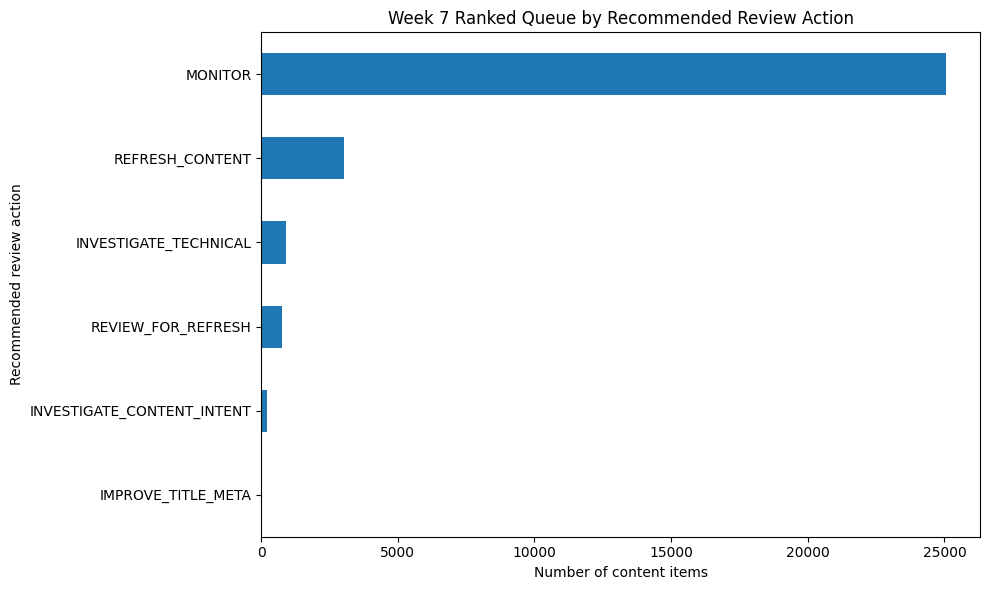

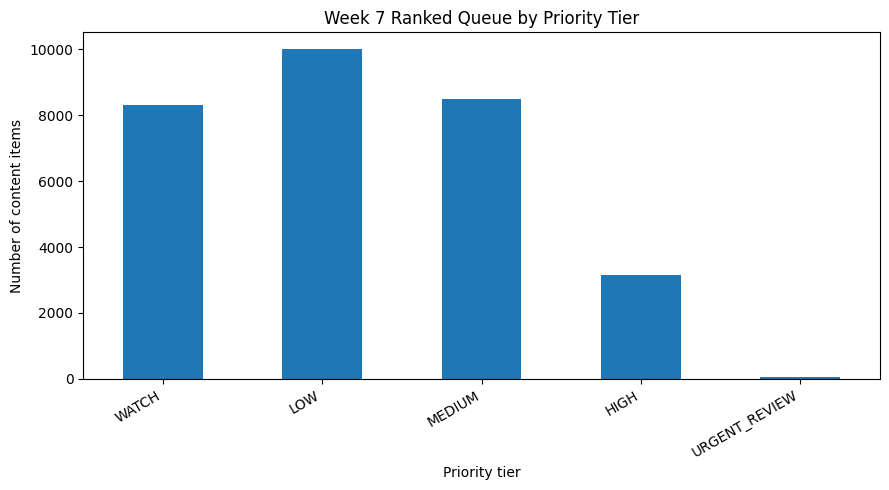

PAPER EXPORTS CREATED
----------------------------------------------------------------------
Queue CSV:       /content/flyrank-ml-internship-sunaina/work/outputs/w07_ranked_action_queue.csv
Metrics JSON:    /content/flyrank-ml-internship-sunaina/work/outputs/w07_playbook_metrics.json
Monitoring JSON: /content/flyrank-ml-internship-sunaina/work/outputs/w07_monitoring_rules.json
Action figure:   /content/flyrank-ml-internship-sunaina/work/figures/w07_action_distribution.png
Priority figure: /content/flyrank-ml-internship-sunaina/work/figures/w07_priority_distribution.png

Important Git rule:
- The queue CSV is regenerated and normally stays out of Git.
- Commit the executed notebook, aggregate JSON receipts, and reusable figures.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 5 — EXPORT QUEUE, METRICS, RULES, AND FIGURES
# ============================================================

# ------------------------------------------------------------
# 1. Define export paths
# ------------------------------------------------------------

queue_export_path = (
    outputs_dir / "w07_ranked_action_queue.csv"
)

metrics_export_path = (
    outputs_dir / "w07_playbook_metrics.json"
)

monitoring_export_path = (
    outputs_dir / "w07_monitoring_rules.json"
)

action_figure_path = (
    figures_dir / "w07_action_distribution.png"
)

priority_figure_path = (
    figures_dir / "w07_priority_distribution.png"
)

# ------------------------------------------------------------
# 2. Privacy-safe export checks
# ------------------------------------------------------------

forbidden_export_terms = [
    "url",
    "query",
    "keyword",
    "title",
    "content_text",
    "body",
    "client_name",
    "domain",
]

forbidden_columns_found = [
    column
    for column in ranked_action_queue.columns
    if any(
        forbidden_term in column.lower()
        for forbidden_term in forbidden_export_terms
    )
]

assert forbidden_columns_found == [], (
    "Private or unsafe columns were found in the export: "
    f"{forbidden_columns_found}"
)

assert ranked_action_queue["content_id"].notna().all()
assert ranked_action_queue["action_rank"].is_unique
assert ranked_action_queue["decision_score"].between(0, 100).all()
assert ranked_action_queue["human_review_required"].all()
assert not ranked_action_queue["automatic_execution_allowed"].any()

# ------------------------------------------------------------
# 3. Export the ranked queue
# ------------------------------------------------------------

ranked_action_queue.to_csv(
    queue_export_path,
    index=False
)

# ------------------------------------------------------------
# 4. Build aggregate metrics receipt
# ------------------------------------------------------------

playbook_metrics = {
    "assignment": "Week 7 Content Action Playbook",
    "lane": "Refresh / Content Opportunity Scoring",
    "source_file": str(source_path.relative_to(repo_root)),
    "source_kind": source_kind,
    "score_source": score_source,
    "queue_rows": int(len(ranked_action_queue)),
    "unique_content_items": int(
        ranked_action_queue["content_id"].nunique()
    ),
    "unique_clients": int(
        ranked_action_queue["client_id"].nunique()
    ),
    "score_scale": "0–100",
    "score_mean": round(
        float(ranked_action_queue["decision_score"].mean()),
        4
    ),
    "score_median": round(
        float(ranked_action_queue["decision_score"].median()),
        4
    ),
    "thresholds": {
        "stale_days": round(float(stale_threshold), 4),
        "high_visibility_impressions": round(
            float(high_visibility_threshold),
            4
        ),
        "strong_position_maximum": round(
            float(strong_position_threshold),
            4
        ),
        "low_ctr_maximum": round(
            float(low_ctr_threshold),
            6
        ),
        "low_sessions_maximum": round(
            float(low_session_threshold),
            4
        ),
    },
    "action_distribution": {
        str(row["recommended_action"]): {
            "queue_items": int(row["queue_items"]),
            "queue_share": round(float(row["queue_share"]), 6),
        }
        for _, row in action_distribution.iterrows()
    },
    "priority_distribution": {
        str(row["priority_tier"]): {
            "queue_items": int(row["queue_items"]),
            "queue_share": round(float(row["queue_share"]), 6),
        }
        for _, row in priority_distribution.iterrows()
    },
    "intended_use": intended_use,
    "known_limits": known_limits,
    "human_review_required_for_every_item": True,
    "automatic_execution_allowed": False,
    "private_text_exported": False,
    "causal_claim_made": False,
}

with open(
    metrics_export_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        playbook_metrics,
        file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# 5. Export monitoring and no-go rules
# ------------------------------------------------------------

monitoring_rules_export = {
    "monitoring_baseline": monitoring_baseline,
    "retrain_or_revalidation_triggers": retrain_triggers,
    "stop_use_conditions": stop_use_conditions,
    "human_review_rules": human_review_rules.to_dict(
        orient="records"
    ),
    "no_go_automation": no_go_automation,
    "no_go_cases": no_go_cases,
    "automatic_retraining_allowed": False,
    "automatic_content_changes_allowed": False,
}

with open(
    monitoring_export_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        monitoring_rules_export,
        file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# 6. Reusable figure: action distribution
# ------------------------------------------------------------

action_plot_data = (
    ranked_action_queue["recommended_action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
action_plot_data.plot(kind="barh")
plt.title("Week 7 Ranked Queue by Recommended Review Action")
plt.xlabel("Number of content items")
plt.ylabel("Recommended review action")
plt.tight_layout()
plt.savefig(
    action_figure_path,
    dpi=180,
    bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7. Reusable figure: priority distribution
# ------------------------------------------------------------

priority_order = [
    "WATCH",
    "LOW",
    "MEDIUM",
    "HIGH",
    "URGENT_REVIEW",
]

priority_plot_data = (
    ranked_action_queue["priority_tier"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
)

plt.figure(figsize=(9, 5))
priority_plot_data.plot(kind="bar")
plt.title("Week 7 Ranked Queue by Priority Tier")
plt.xlabel("Priority tier")
plt.ylabel("Number of content items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    priority_figure_path,
    dpi=180,
    bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# 8. Verify every required export
# ------------------------------------------------------------

required_exports = [
    queue_export_path,
    metrics_export_path,
    monitoring_export_path,
    action_figure_path,
    priority_figure_path,
]

for export_path in required_exports:
    assert export_path.exists(), (
        f"Required export was not created: {export_path}"
    )

assert queue_export_path.stat().st_size > 0
assert metrics_export_path.stat().st_size > 0
assert monitoring_export_path.stat().st_size > 0
assert action_figure_path.stat().st_size > 0
assert priority_figure_path.stat().st_size > 0

print("PAPER EXPORTS CREATED")
print("-" * 70)
print(f"Queue CSV:       {queue_export_path}")
print(f"Metrics JSON:    {metrics_export_path}")
print(f"Monitoring JSON: {monitoring_export_path}")
print(f"Action figure:   {action_figure_path}")
print(f"Priority figure: {priority_figure_path}")

print("\nImportant Git rule:")
print(
    "- The queue CSV is regenerated and normally stays out of Git."
)
print(
    "- Commit the executed notebook, aggregate JSON receipts, "
    "and reusable figures."
)

## 5. Exports for the paper

The notebook exports the practical queue and aggregate evidence needed by the final research paper.

### Exported queue

The ranked CSV contains pseudonymized identifiers and decision-support fields. It intentionally excludes:

- Client names
- URLs
- Search-query text
- Page titles
- Page content
- Private notes
- Raw model objects

The queue CSV is regenerated by this notebook and remains outside Git because the repository leak guard blocks data files.

### Committed receipts

The aggregate JSON files contain no row-level private data. They record:

- Queue size
- Score source
- Thresholds
- Action distribution
- Priority distribution
- Intended use
- Known limits
- Human-review requirement
- Monitoring baseline
- Retrain triggers
- Stop-use conditions

These JSON files are the traceable receipts for the recommendations section of the paper.

### Reusable figures

The notebook saves aggregate figures under `work/figures/`. These figures can be committed and reused in the deployed research paper because they show aggregate action and priority distributions rather than private row-level data.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [ ]:
# ============================================================
# SECTION 6 — FINAL WEEK 7 ASSIGNMENT VERIFICATION
# ============================================================

required_queue_columns = {
    "action_rank",
    "content_id",
    "decision_score",
    "priority_tier",
    "recommended_action",
    "reason_code",
    "reason_explanation",
    "confidence_note",
    "estimated_effort",
    "estimated_review_time",
    "potential_value",
    "human_review_required",
    "automatic_execution_allowed",
}

missing_required_columns = sorted(
    required_queue_columns.difference(
        ranked_action_queue.columns
    )
)

assert missing_required_columns == [], (
    "The ranked queue is missing required columns: "
    f"{missing_required_columns}"
)

assert len(ranked_action_queue) > 0, (
    "The ranked action queue is empty."
)

assert ranked_action_queue["action_rank"].is_unique, (
    "Action ranks must be unique."
)

assert ranked_action_queue["action_rank"].min() == 1, (
    "Action ranking must start at 1."
)

assert ranked_action_queue["decision_score"].between(
    0,
    100
).all(), "All decision scores must be between 0 and 100."

assert ranked_action_queue["reason_code"].notna().all(), (
    "Every queue item must have a reason code."
)

assert ranked_action_queue[
    "recommended_action"
].notna().all(), (
    "Every queue item must have a recommended action."
)

assert ranked_action_queue[
    "human_review_required"
].all(), (
    "Every queue item must require human review."
)

assert not ranked_action_queue[
    "automatic_execution_allowed"
].any(), (
    "No queue item may allow automatic execution."
)

assert len(archetype_action_mapping) >= 5, (
    "The archetype-to-action mapping is incomplete."
)

assert len(human_review_rules) >= 8, (
    "The human-review process is incomplete."
)

assert len(no_go_automation) >= 10, (
    "The no-go automation list is incomplete."
)

assert len(retrain_triggers) >= 6, (
    "The retrain/revalidation trigger list is incomplete."
)

assert all(
    trigger["automatic_retrain"] is False
    for trigger in retrain_triggers
), "Retraining must not happen automatically."

for export_path in [
    queue_export_path,
    metrics_export_path,
    monitoring_export_path,
    action_figure_path,
    priority_figure_path,
]:
    assert export_path.exists(), (
        f"Missing required export: {export_path}"
    )

forbidden_final_columns = [
    column
    for column in ranked_action_queue.columns
    if any(
        term in column.lower()
        for term in [
            "url",
            "query",
            "keyword",
            "title",
            "content_text",
            "body",
            "client_name",
            "domain",
        ]
    )
]

assert forbidden_final_columns == [], (
    "Unsafe export columns were found: "
    f"{forbidden_final_columns}"
)

print("FINAL WEEK 7 SELF-CHECK")
print("-" * 70)
print("Ranked action queue created: YES")
print("Ranked actions assigned: YES")
print("Reason codes assigned: YES")
print("Archetype-to-action mapping included: YES")
print("Decay and refresh insight documented: YES")
print("Intended use documented: YES")
print("Known limits documented: YES")
print("Cost and value thinking included: YES")
print("Human-review process documented: YES")
print("Human review required for every item: YES")
print("Automatic content execution allowed: NO")
print("No-go automation list documented: YES")
print("Monitoring metrics documented: YES")
print("Retrain/revalidation triggers documented: YES")
print("Automatic retraining allowed: NO")
print("Stop-use conditions documented: YES")
print("Private URLs or query text exported: NO")
print("Queue CSV exported: YES")
print("Metrics JSON exported: YES")
print("Monitoring JSON exported: YES")
print("Reusable action figure exported: YES")
print("Reusable priority figure exported: YES")
print("Claims remain directional and decision-support based: YES")
print("All verification assertions passed.")

print("\nFINAL ASSIGNMENT SUMMARY")
print("-" * 70)
print("Lane: Refresh / Content Opportunity Scoring")
print(f"Score source: {score_source}")
print(f"Ranked queue rows: {len(ranked_action_queue):,}")
print(
    "Highest decision score: "
    f"{ranked_action_queue['decision_score'].max():.2f}"
)
print(
    "Median decision score: "
    f"{ranked_action_queue['decision_score'].median():.2f}"
)
print(
    "Urgent-review items: "
    f"{(ranked_action_queue['priority_tier'] == 'URGENT_REVIEW').sum():,}"
)
print(
    "High-priority items: "
    f"{(ranked_action_queue['priority_tier'] == 'HIGH').sum():,}"
)
print(f"Queue CSV: {queue_export_path}")
print(f"Metrics receipt: {metrics_export_path}")
print(f"Monitoring receipt: {monitoring_export_path}")
print(f"Action figure: {action_figure_path}")
print(f"Priority figure: {priority_figure_path}")

FINAL WEEK 7 SELF-CHECK
----------------------------------------------------------------------
Ranked action queue created: YES
Ranked actions assigned: YES
Reason codes assigned: YES
Archetype-to-action mapping included: YES
Decay and refresh insight documented: YES
Intended use documented: YES
Known limits documented: YES
Cost and value thinking included: YES
Human-review process documented: YES
Human review required for every item: YES
Automatic content execution allowed: NO
No-go automation list documented: YES
Monitoring metrics documented: YES
Retrain/revalidation triggers documented: YES
Automatic retraining allowed: NO
Stop-use conditions documented: YES
Private URLs or query text exported: NO
Queue CSV exported: YES
Metrics JSON exported: YES
Monitoring JSON exported: YES
Reusable action figure exported: YES
Reusable priority figure exported: YES
Claims remain directional and decision-support based: YES
All verification assertions passed.

FINAL ASSIGNMENT SUMMARY
------------